In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("cleaned_sales_data.csv")

In [2]:
#Customer Purchase summary

customer_summary = data.groupby(
    'Customer_ID'
).agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Number_of_Orders=('Order_ID', 'nunique'),
    Average_Order_Value=('Revenue', 'mean'),
    Customer_Age=('Customer_Age', 'first'),
    City=('City', 'first')
).reset_index()

customer_summary.head()

,Customer_ID,Total_Revenue,Total_Quantity,Number_of_Orders,Average_Order_Value,Customer_Age,City
0,C1001,211000.0,9.0,2,105500.0,46.0,Unknown
1,C1002,45000.0,4.0,1,45000.0,24.0,Pune
2,C1003,10392.0,8.0,1,10392.0,999.0,Jaipur
3,C1005,50194.0,6.0,2,25097.0,28.0,Kolkata
4,C1008,74997.0,3.0,1,74997.0,47.0,Delhi


In [3]:
#Most valuable Customer

top_customers = customer_summary.sort_values(
    'Total_Revenue',
    ascending=False
)

top_customers.head(10)

,Customer_ID,Total_Revenue,Total_Quantity,Number_of_Orders,Average_Order_Value,Customer_Age,City
102,C1125,600794.0,18.0,4,150198.5,33.0,Ahmedabad
21,C1028,599790.0,20.0,4,149947.5,44.0,Jaipur
76,C1095,483993.0,12.0,3,161331.0,45.0,Kolkata
154,C1185,471999.0,13.0,3,157333.0,29.0,Lucknow
172,C1204,439998.0,6.0,2,219999.0,43.0,Hyderabad
25,C1034,424992.0,12.0,3,141664.0,27.0,Pune
122,C1148,412981.0,27.0,5,82596.2,50.0,Pune
65,C1081,410974.0,26.0,5,82194.8,44.0,Delhi
92,C1115,396494.0,16.0,4,99123.5,27.0,Delhi
163,C1195,379992.0,13.0,3,126664.0,65.0,Ahmedabad


In [4]:
#Revenue By City

city_customer_analysis = customer_summary.groupby(
    'City'
).agg(
    Customers=('Customer_ID', 'nunique'),
    Revenue=('Total_Revenue', 'sum'),
    Average_Customer_Revenue=('Total_Revenue', 'mean')
).sort_values(
    'Revenue',
    ascending=False
)

city_customer_analysis

,Customers,Revenue,Average_Customer_Revenue
City,,,
Pune,24,3163302.0,131804.250000
Lucknow,22,2731155.0,124143.409091
Kolkata,23,2666231.0,115923.086957
Ahmedabad,22,2560140.0,116370.000000
Delhi,16,2466021.0,154126.312500
Jaipur,20,2095610.0,104780.500000
Hyderabad,22,1961232.0,89146.909091
Chennai,22,1869920.0,84996.363636
Bangalore,23,1856940.0,80736.521739


In [6]:
#Age Segementation

customer_summary['Age_Group'] = pd.cut(
    customer_summary['Customer_Age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=[
        '18-25',
        '26-35',
        '36-50',
        '51-65',
        '66+'
    ]
)

In [8]:
#Revenue by Age Group

age_analysis = customer_summary.groupby(
    'Age_Group',
    observed=True
)['Total_Revenue'].agg(
    ['sum', 'mean', 'count']
)

age_analysis

,sum,mean,count
Age_Group,,,
18-25,3542423.0,98400.638889,36
26-35,5723381.0,124421.326087,46
36-50,7784114.0,109635.408451,71
51-65,6368368.0,111725.754386,57


In [9]:
#Customer Segmentation based on Spending

customer_summary['Customer_Segment'] = pd.qcut(
    customer_summary['Total_Revenue'],
    q=3,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value'
    ],
    duplicates='drop'
)

In [10]:
#Segment Analysis

segment_analysis = customer_summary.groupby(
    'Customer_Segment',
    observed=True
).agg(
    Customers=('Customer_ID', 'count'),
    Total_Revenue=('Total_Revenue', 'sum'),
    Average_Revenue=('Total_Revenue', 'mean')
)

segment_analysis

,Customers,Total_Revenue,Average_Revenue
Customer_Segment,,,
Low Value,71,739723.0,10418.633803
Medium Value,70,5263314.0,75190.200000
High Value,71,17473133.0,246100.464789


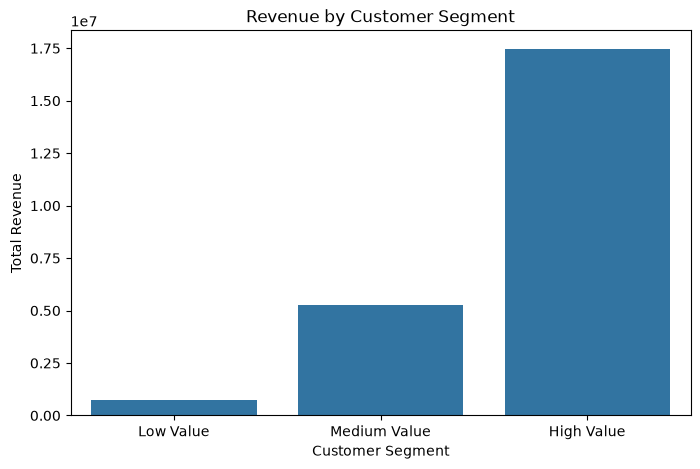

In [11]:
#Customer Segment Graph

plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_summary,
    x='Customer_Segment',
    y='Total_Revenue',
    estimator='sum',
    errorbar=None
)

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')

plt.show()

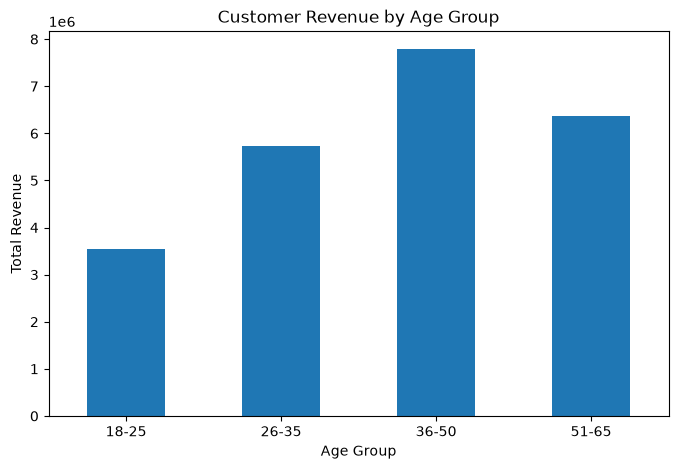

In [12]:
#Age group Graph

plt.figure(figsize=(8, 5))

age_revenue = customer_summary.groupby(
    'Age_Group',
    observed=True
)['Total_Revenue'].sum()

age_revenue.plot(kind='bar')

plt.title('Customer Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()

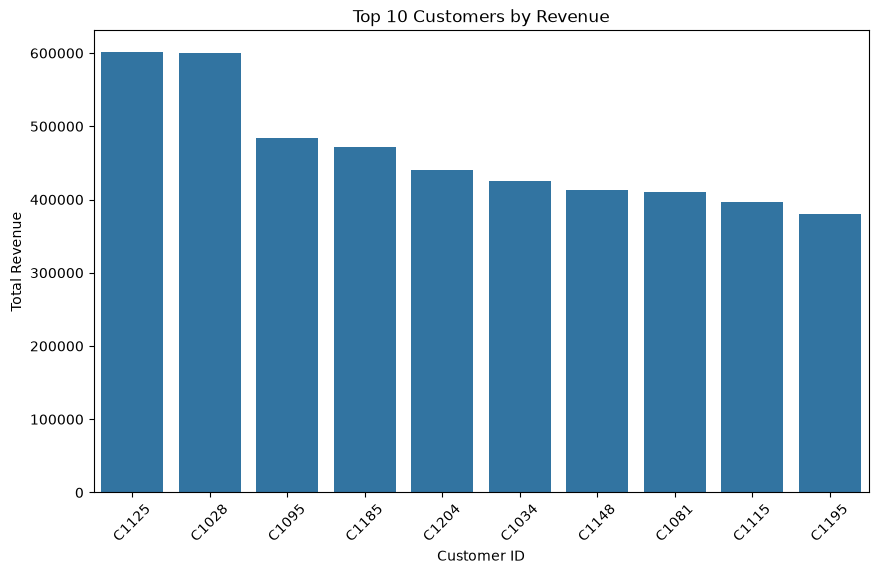

In [13]:
#Top 10 Customers

top10 = customer_summary.nlargest(
    10,
    'Total_Revenue'
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x='Customer_ID',
    y='Total_Revenue'
)

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

In [14]:
#Customer Behaviour

customer_summary[
    [
        'Customer_ID',
        'Total_Revenue',
        'Total_Quantity',
        'Number_of_Orders',
        'Average_Order_Value'
    ]
].sort_values(
    'Total_Revenue',
    ascending=False
).head(10)

,Customer_ID,Total_Revenue,Total_Quantity,Number_of_Orders,Average_Order_Value
102,C1125,600794.0,18.0,4,150198.5
21,C1028,599790.0,20.0,4,149947.5
76,C1095,483993.0,12.0,3,161331.0
154,C1185,471999.0,13.0,3,157333.0
172,C1204,439998.0,6.0,2,219999.0
25,C1034,424992.0,12.0,3,141664.0
122,C1148,412981.0,27.0,5,82596.2
65,C1081,410974.0,26.0,5,82194.8
92,C1115,396494.0,16.0,4,99123.5
163,C1195,379992.0,13.0,3,126664.0


## Marketing Recommendations

### High-Value Customers
Customers in the high-value segment should receive loyalty rewards, personalized offers and early access to new products.

### Medium-Value Customers
Medium-value customers can be encouraged to increase their spending through bundled products, discounts and cross-selling.

### Low-Value Customers
Low-value customers can be targeted with introductory discounts and personalized recommendations.

### Age-Based Marketing
Marketing campaigns can be customized according to the purchasing behavior of different age groups.

### City-Based Marketing
Cities generating higher revenue can receive more promotional campaigns and targeted offers.